In [52]:

import tensorflow as tf
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
import numpy as np
import random
import datetime
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import h5py
import os
from sklearn.metrics import roc_curve, auc
from sklearn.manifold import TSNE
import yaml
import regex as re
from pathlib import Path

In [53]:
train_data_file = "train_binned_tokens_split_encoded_filtered_binary.h5"
val_data_file = "val_binned_tokens_split_encoded_filtered_binary.h5"
test_data_file = "test_binned_tokens_split_encoded_filtered_binary.h5"


hf_train = h5py.File(train_data_file, 'r')
hf_test = h5py.File(test_data_file, 'r')
hf_val = h5py.File(val_data_file, 'r')

In [55]:
"""
Define the folder in which you want the model and the other files to be saved.
"""
local_repo= "C:\\Users\\revel\\Downloads\\New folder (2)\\ACP_data"

In [56]:
"""
GPU strategy for distributed training.
This code sets up a strategy for distributed training using multiple GPUs.
"""

print("Num GPUs Available:", torch.cuda.device_count())
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

amp_scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())

Num GPUs Available: 0


C:\Users\revel\AppData\Local\Temp\ipykernel_292\3452559175.py:9: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  amp_scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())


In [57]:
""" 
Classes for the Transformer model and its components.
These classes include the MultiHeadAttention, TransformerBlock, PositionalEncoding,
FeedForwardNetwork, and Transformer classes.
"""
#register_keras_serializable
#@register_pytorch_serializable(package='Custom', name='PositionalEncoding')
class PositionalEncoding(nn.Module):
    def __init__(self, hidden_size: int, max_len: int = 5000):
        super().__init__()
        pe = torch.zeros(max_len, hidden_size)
        pos = torch.arange(0, max_len).unsqueeze(1)
        div = torch.exp(torch.arange(0, hidden_size, 2).float() * (-np.log(10000.0) / hidden_size))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0))  # (1, max_len, hidden_size)
    
    def forward(self, x):  # x: (batch, seq_len, hidden_size)
        return x + self.pe[:, :x.size(1), :]







#@register_keras_serializable(package='Custom', name='TransformerLayer')
class TransformerBlock(nn.Module):
    def __init__(self, hidden_size, num_heads, dropout_rate=0.1):
        super().__init__()
        self.attn = nn.MultiheadAttention(
            embed_dim=hidden_size,
            num_heads=num_heads,
            dropout=dropout_rate,
            batch_first=True
        )
        self.norm1 = nn.LayerNorm(hidden_size)
        self.norm2 = nn.LayerNorm(hidden_size)
        self.ff = nn.Sequential(
            nn.Linear(hidden_size, 4 * hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(4 * hidden_size, hidden_size)
        )
        self.dropout = nn.Dropout(dropout_rate)

    def forward(self, x, key_padding_mask=None, attn_mask=None):
        attn_out, _ = self.attn(
            x, x, x,
            key_padding_mask=key_padding_mask,
            attn_mask=attn_mask
        )
        x = self.norm1(x + self.dropout(attn_out))
        ff_out = self.ff(x)
        x = self.norm2(x + self.dropout(ff_out))
        return x
    

class TransformerClassifier(nn.Module):
    def __init__(self, vocab_size, hidden_size, num_layers, num_heads,
                num_classes=2, dropout_rate=0.1, max_len=512):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, hidden_size)
        self.posenc = PositionalEncoding(hidden_size, max_len=max_len)
        self.layers = nn.ModuleList([
            TransformerBlock(hidden_size, num_heads, dropout_rate)
            for _ in range(num_layers)
        ])
        self.dropout = nn.Dropout(dropout_rate)
        self.classifier = nn.Linear(hidden_size, num_classes)

    def forward(self, tokens):
        x = self.embed(tokens)
        x = self.posenc(x)

        for layer in self.layers:
            x = layer(x)

        x = x.mean(dim=1)
        x = self.dropout(x)
        logits = self.classifier(x)
        return logits




In [58]:
""" 
Hyperparameters and early stopping parameters.
These parameters are used to configure the training process.
"""
# Access hyperparameters
max_index_maskable = 18
mask_token_id = 163
vocab_size = 164
hidden_size = 64
num_layers = 2
num_heads = 4
num_epochs = 10
dropout_rate = 0.1

In [59]:
from torch.utils.data import TensorDataset, DataLoader
import torch
import numpy as np

def make_dataloaders(batch_size: int = 512):
    X_train = torch.tensor(np.array(hf_train["features"]), dtype=torch.long)
    y_train = torch.tensor(np.array(hf_train["source_file"]))

    X_val = torch.tensor(np.array(hf_val["features"]), dtype=torch.long)
    y_val = torch.tensor(np.array(hf_val["source_file"]))

    X_test = torch.tensor(np.array(hf_test["features"]), dtype=torch.long)
    y_test = torch.tensor(np.array(hf_test["source_file"]))

    train_ds = TensorDataset(X_train, y_train)
    val_ds   = TensorDataset(X_val, y_val)
    test_ds  = TensorDataset(X_test, y_test)

    seq_len = X_train.shape[1]

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=0, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)
    test_loader  = DataLoader(test_ds,  batch_size=1,          shuffle=False, num_workers=0, pin_memory=True)

    meta = dict(
        vocab_size=vocab_size,
        max_index_maskable=max_index_maskable,
        seq_len=seq_len,
        Ntrain=len(train_ds),
        Nval=len(val_ds),
        Ntest=len(test_ds),
    )
    return train_loader, val_loader, test_loader, meta

In [60]:
batch_size = 512
train_loader, val_loader, test_loader, meta = make_dataloaders(
    batch_size=batch_size,
    )



print("Meta:", meta)

# Grab one batch from train/val/test
train_tokens, train_labels = next(iter(train_loader))
val_tokens,   val_labels   = next(iter(val_loader))
test_tokens,  test_labels  = next(iter(test_loader))

print("Train batch:", train_tokens.shape, train_labels.shape)
print("Val batch:  ", val_tokens.shape,   val_labels.shape)
print("Test batch: ", test_tokens.shape,  test_labels.shape)

print("Train labels:", train_labels.shape)

print("Val labels:", val_labels.shape)

print("Test labels:", test_labels.shape)

Meta: {'vocab_size': 164, 'max_index_maskable': 18, 'seq_len': 19, 'Ntrain': 178308, 'Nval': 19806, 'Ntest': 19811}
Train batch: torch.Size([512, 19]) torch.Size([512])
Val batch:   torch.Size([512, 19]) torch.Size([512])
Test batch:  torch.Size([1, 19]) torch.Size([1])
Train labels: torch.Size([512])
Val labels: torch.Size([512])
Test labels: torch.Size([1])


In [61]:
"""
Check if the repertory where the model will be saved exists.
If not, create it.
And verify if the folder where the embeddings will be saved exists, or creates it if it does not. 
"""

begin=str(datetime.datetime.now().strftime("%Y%m%d-%H%M"))
#os.makedirs("saved_models", exist_ok=True)
repo_name = os.path.join(local_repo, f"ACP_MASK{batch_size}_{begin}")
os.makedirs(repo_name, exist_ok=True)
os.makedirs(repo_name + "/embeddings_plots", exist_ok=True)

In [62]:
""" 
Definition the model, loss, and optimizer inside the strategy scope
To distribute training across multiple GPUs on the same machine:
"""
#with strategy.scope():
    # Create the autoregressive transformer model
model = TransformerClassifier(
    vocab_size=vocab_size,
    hidden_size=hidden_size,
    num_layers=num_layers,
    num_heads=num_heads,
    num_classes=2,
    dropout_rate=dropout_rate,
    max_len=meta["seq_len"]
).to(device)

loss_function = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)



Starting training...
Epoch 1/10


C:\Users\revel\AppData\Local\Temp\ipykernel_292\56931359.py:59: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


Epoch 1/10 - Loss: 0.3655 - Val Loss: 0.3471 - Val Acc: 0.8665


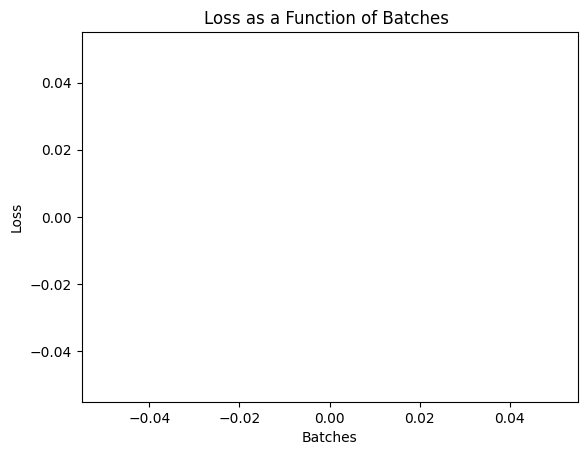

Epoch 2/10
Epoch 2/10 - Loss: 0.3411 - Val Loss: 0.3398 - Val Acc: 0.8697


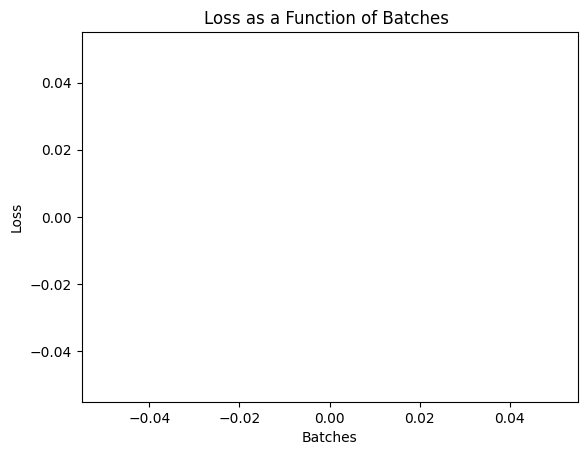

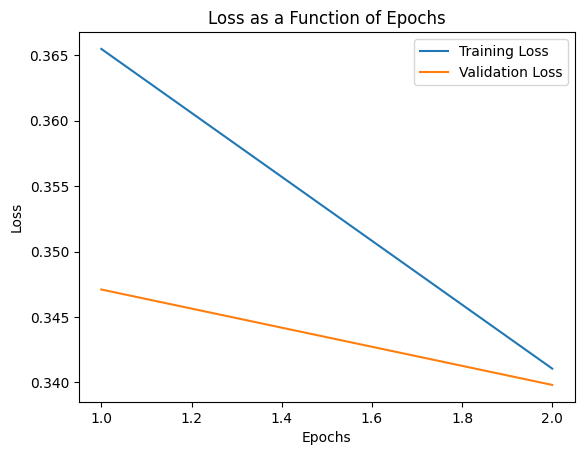

Epoch 3/10
Epoch 3/10 - Loss: 0.3370 - Val Loss: 0.3386 - Val Acc: 0.8695


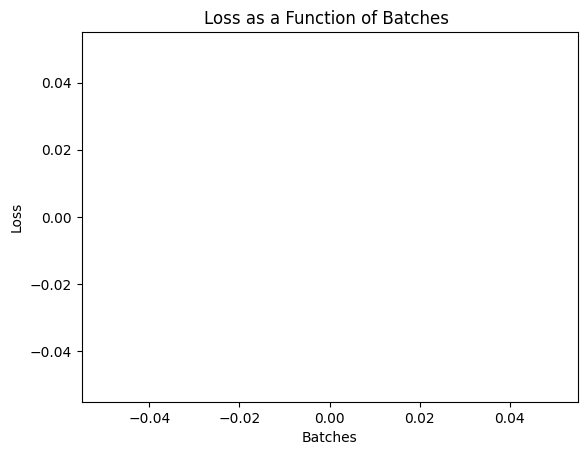

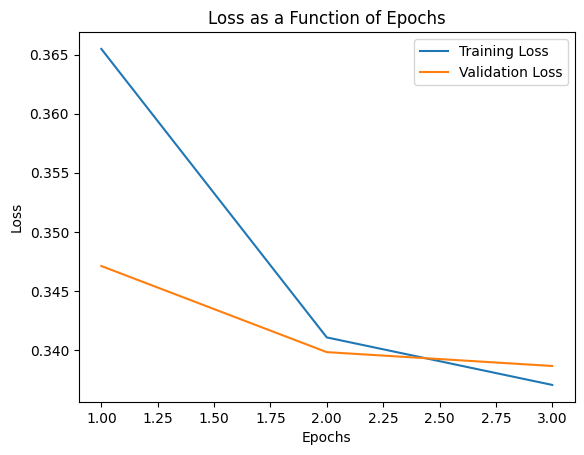

Epoch 4/10
Epoch 4/10 - Loss: 0.3357 - Val Loss: 0.3380 - Val Acc: 0.8688


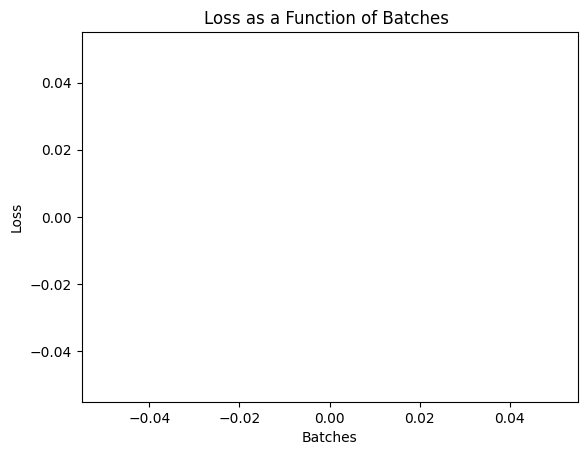

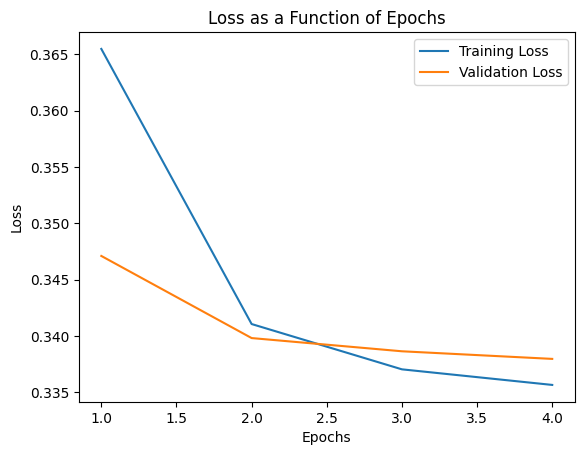

Epoch 5/10
Epoch 5/10 - Loss: 0.3349 - Val Loss: 0.3384 - Val Acc: 0.8683


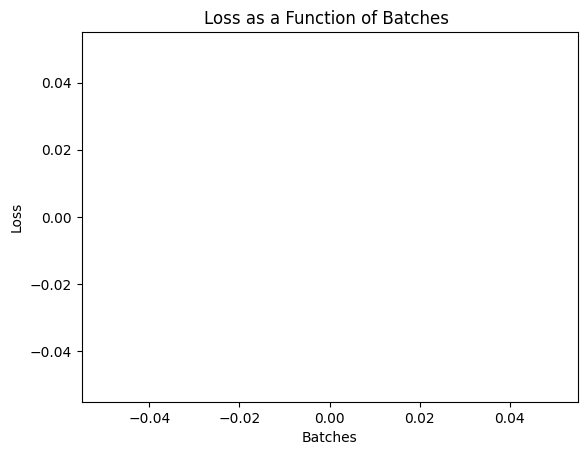

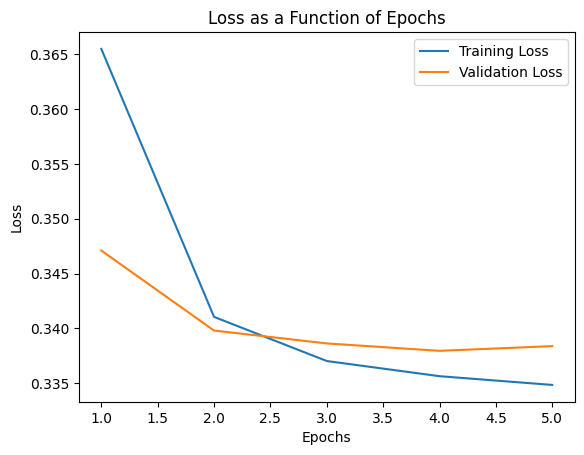

Epoch 6/10
Epoch 6/10 - Loss: 0.3341 - Val Loss: 0.3381 - Val Acc: 0.8693


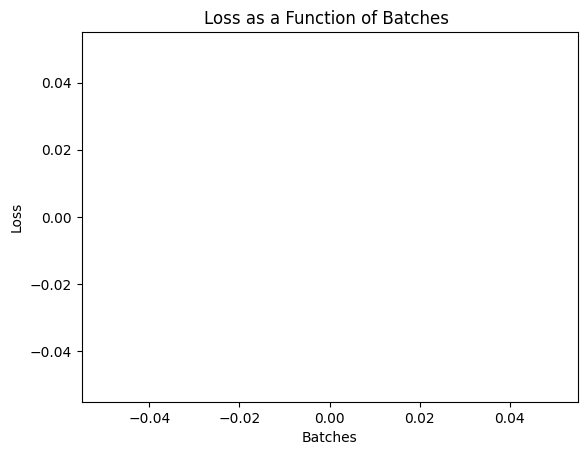

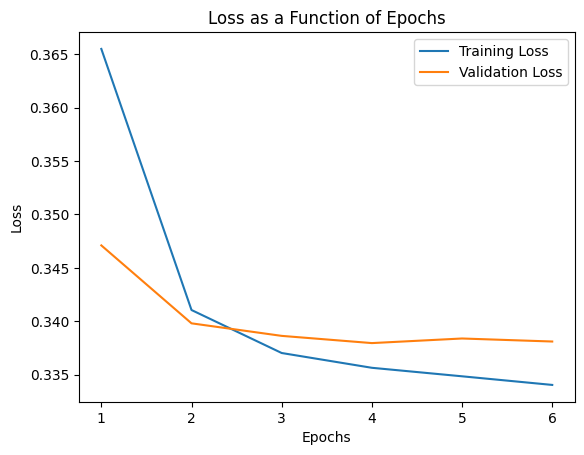

Epoch 7/10
Epoch 7/10 - Loss: 0.3332 - Val Loss: 0.3386 - Val Acc: 0.8698


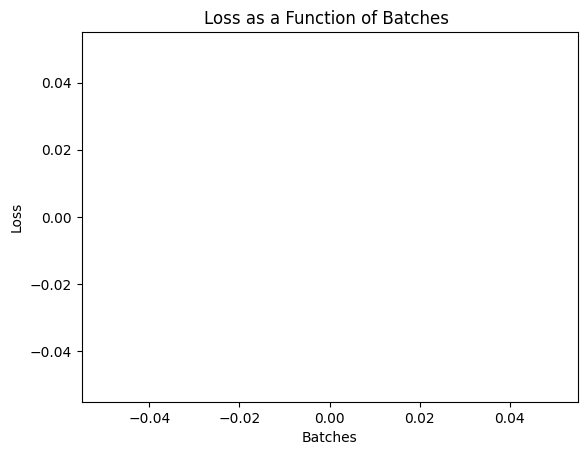

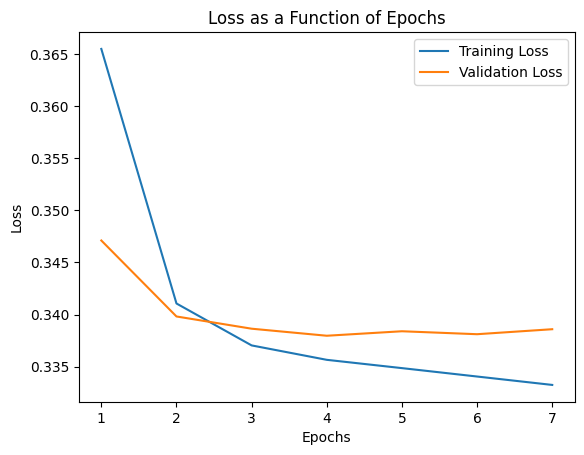

Epoch 8/10
Epoch 8/10 - Loss: 0.3326 - Val Loss: 0.3378 - Val Acc: 0.8693


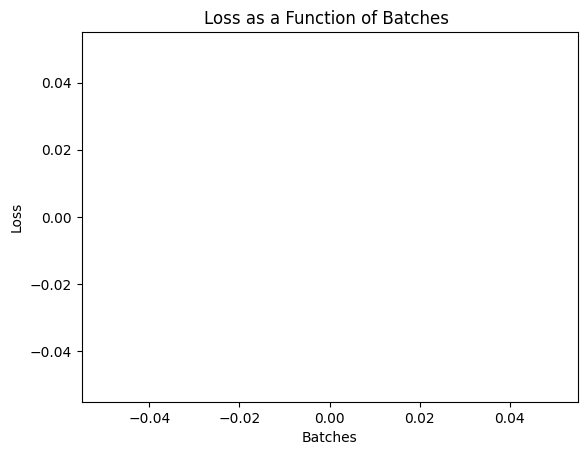

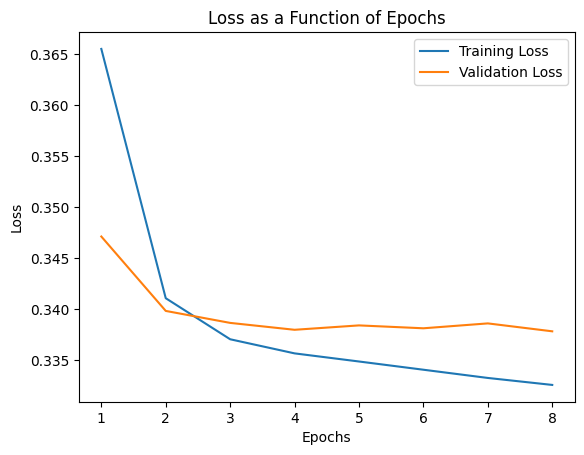

Epoch 9/10
Epoch 9/10 - Loss: 0.3318 - Val Loss: 0.3370 - Val Acc: 0.8692


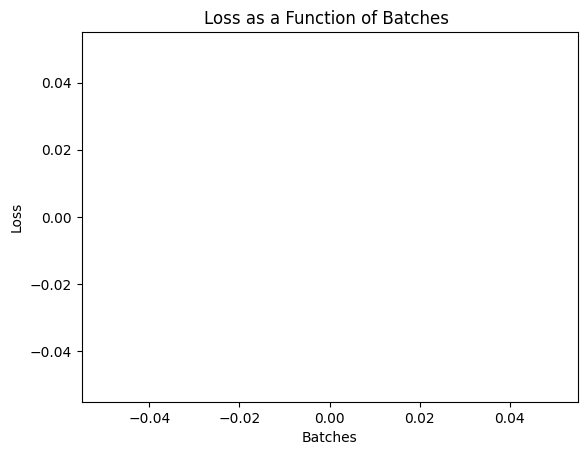

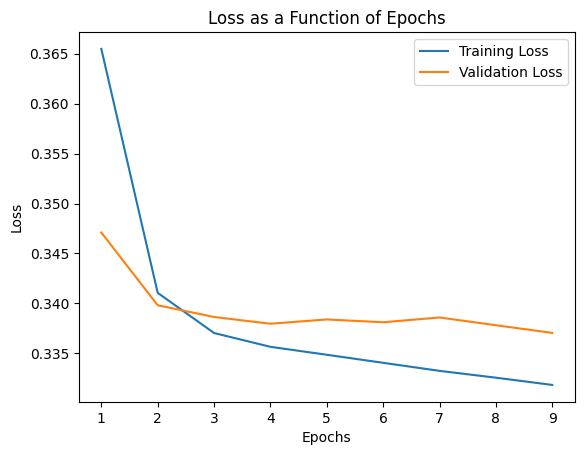

Epoch 10/10
Epoch 10/10 - Loss: 0.3313 - Val Loss: 0.3368 - Val Acc: 0.8678


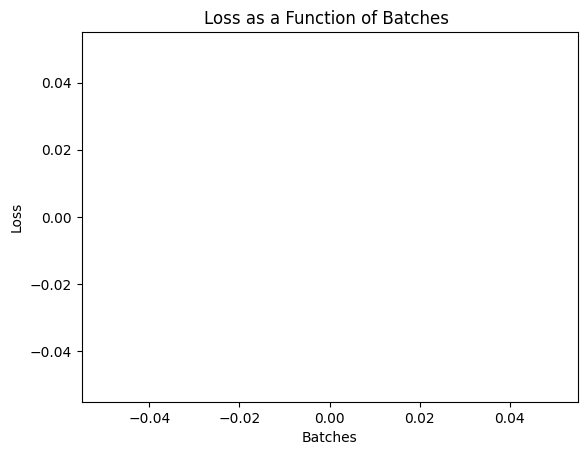

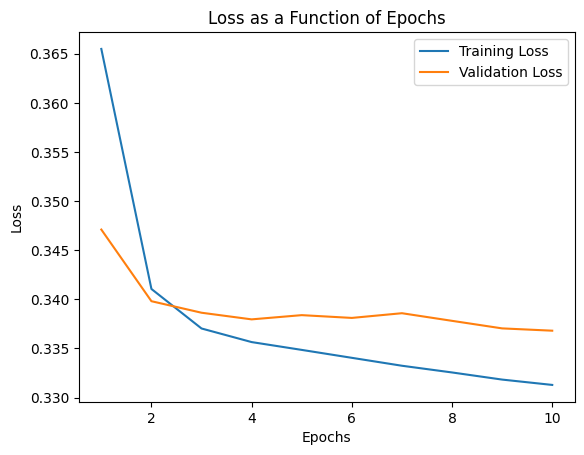

End of training
--------------------


In [63]:


batch_history = []
loss_batch_history = []
epoch_history = []
loss_epoch_history = []
accuracy_history = []
val_loss_history = []


def sample_mask_indices(tokens: torch.Tensor, max_index_maskable: int) -> torch.Tensor:
    """
    Sample one random mask position per sequence in the batch.
    
    Assumes:
    - tokens has shape (B, T)
    - there is no padding
    - all positions 0..max_index_maskable are valid maskable positions
    """
    B, T = tokens.size()

    if max_index_maskable >= T:
        raise ValueError(f"max_index_maskable={max_index_maskable} exceeds sequence length T={T}")

    return torch.randint(
        low=0,
        high=max_index_maskable + 1,
        size=(B,),
        device=tokens.device
    )


def gather_logits_at_positions(logits: torch.Tensor, positions: torch.Tensor) -> torch.Tensor:
    """
    logits:    (B, T, V)
    positions: (B,)
    returns:   (B, V)
    """
    B = logits.size(0)
    row_idx = torch.arange(B, device=logits.device)
    return logits[row_idx, positions, :]






def train_one_epoch_classifier(model, loader, optimizer, loss_function, device, scaler):
    model.train()
    running_loss = 0.0
    total_correct = 0
    total_count = 0
    n_batches = 0

    for tokens, labels in loader:
        tokens = tokens.to(device)
        labels = labels.to(device).long()

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
            logits = model(tokens)                  # (B, 2)
            loss = loss_function(logits, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        preds = logits.argmax(dim=-1)
        total_correct += (preds == labels).sum().item()
        total_count += labels.numel()

        running_loss += loss.item()
        n_batches += 1

    avg_loss = running_loss / max(n_batches, 1)
    acc = total_correct / max(total_count, 1)
    return avg_loss, acc


@torch.no_grad()
def validate_classifier(model, loader, loss_function, device):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_count = 0
    n_batches = 0

    for tokens, labels in loader:
        tokens = tokens.to(device)
        labels = labels.to(device).long()

        logits = model(tokens)
        loss = loss_function(logits, labels)

        preds = logits.argmax(dim=-1)
        total_correct += (preds == labels).sum().item()
        total_count += labels.numel()

        total_loss += loss.item()
        n_batches += 1

    avg_loss = total_loss / max(n_batches, 1)
    acc = total_correct / max(total_count, 1)
    return avg_loss, acc



n_train_data = meta["Ntrain"]
batch_size = train_loader.batch_size or 1

print("\nStarting training...")
for epoch in range(num_epochs):
    print(f"Epoch {epoch+1}/{num_epochs}")




    # ---- Train ----
    avg_train_loss, train_acc = train_one_epoch_classifier(
        model, train_loader, optimizer, loss_function, device, amp_scaler
    )
    loss_epoch_history.append(avg_train_loss)
    epoch_history.append(epoch + 1)

    # ---- Validate ----
    val_loss, val_acc = validate_classifier(
        model, val_loader, loss_function, device
    )
    val_loss_history.append(val_loss)
    accuracy_history.append(val_acc)


    print(f"Epoch {epoch+1}/{num_epochs} - Loss: {avg_train_loss:.4f} - Val Loss: {val_loss:.4f} - Val Acc: {val_acc:.4f}")

# Plot the loss history per batch
    plt.plot(batch_history, loss_batch_history)
    plt.title('Loss as a Function of Batches ')
    plt.xlabel('Batches')
    plt.ylabel('Loss')
    plt.show()
    if epoch+1 != 1:
        # Plot the loss history per epoch
        plt.plot(epoch_history, loss_epoch_history, label='Training Loss')
        plt.plot(epoch_history, val_loss_history, label='Validation Loss')
        plt.title('Loss as a Function of Epochs')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend()
        plt.show()
    
    # Extract and plot embeddings before the epoch
    #embedding_weights = embedding_weights = model.embed.weight.detach().cpu().numpy()  # Get the embedding layer weights
    #plot_embeddings_tSNE(embedding_weights, epoch, np.arange(1,vocab_size), repo_name, vocab_size=vocab_size-1)
    
    
# End of training
end=str(datetime.datetime.now().strftime("%Y%m%d-%H%M"))
print(f"End of training")
print("--------------------")


In [64]:
"""
Save the PyTorch model
"""
# Base save path
name_model = os.path.join(repo_name, "pt_model")

# Ensure the directory exists
os.makedirs(repo_name, exist_ok=True)

#  Save only model weights (analogous to .weights.h5)
weights_path = name_model + ".weights.pt"
torch.save(model.state_dict(), weights_path)

#  Save full checkpoint (model + optimizer + epoch etc.)
checkpoint_path = name_model + ".checkpoint.pt"
torch.save({
    "epoch": epoch + 1,
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "loss": loss_epoch_history[-1] if len(loss_epoch_history) > 0 else None,
    "meta": meta
}, checkpoint_path)

full_model_path = name_model + ".pt"
torch.save(model, full_model_path)


print(f"Model weights saved to {weights_path}")
print(f"Full checkpoint saved to {checkpoint_path}")

Model weights saved to C:\Users\revel\Downloads\New folder (2)\ACP_data\ACP_MASK512_20260407-1936\pt_model.weights.pt
Full checkpoint saved to C:\Users\revel\Downloads\New folder (2)\ACP_data\ACP_MASK512_20260407-1936\pt_model.checkpoint.pt


In [65]:
"""
Save the training history and run info
"""

# Ensure output directory exists
os.makedirs(repo_name, exist_ok=True)

# Save as compressed NumPy archive
history_path = os.path.join(repo_name, "training_history.npz")

np.savez(
    history_path,
    batch_history=np.array(batch_history, dtype=float),
    loss_batch_history=np.array(loss_batch_history, dtype=float),
    epoch_history=np.array(epoch_history, dtype=float),
    loss_epoch_history=np.array(loss_epoch_history, dtype=float),
    accuracy_history=np.array(accuracy_history, dtype=float),
    val_loss_history=np.array(val_loss_history, dtype=float),
)

print(f"Training history saved as {history_path}")


Training history saved as C:\Users\revel\Downloads\New folder (2)\ACP_data\ACP_MASK512_20260407-1936\training_history.npz


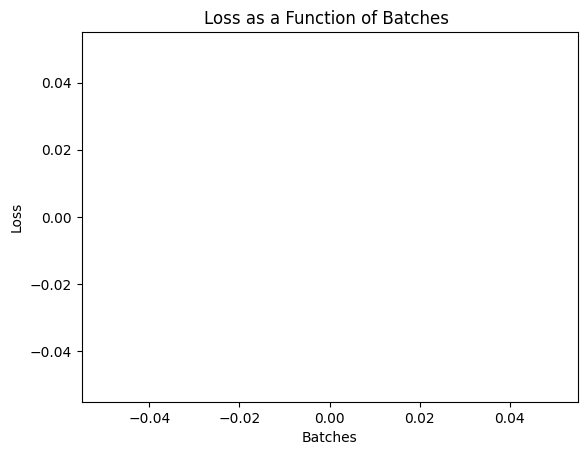

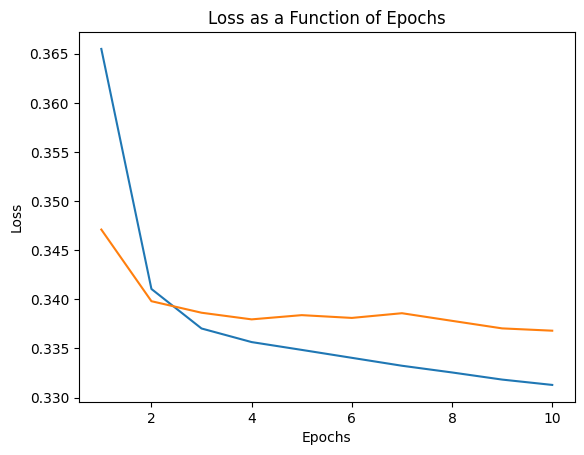

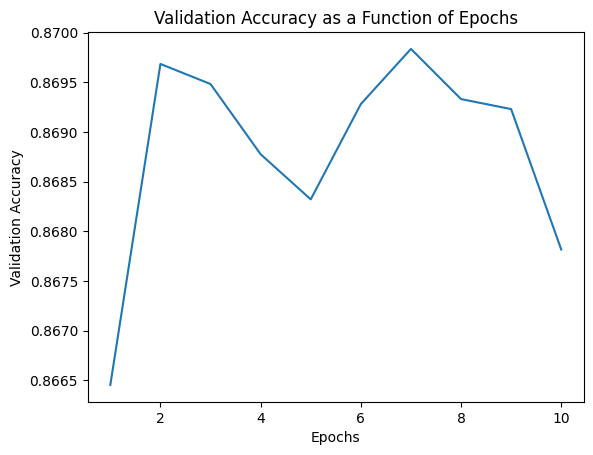

In [66]:
"""
Plots
"""
# Plot the loss history per batch
plt.figure()
plt.plot(batch_history, loss_batch_history)
#plt.yscale("log")
plt.title('Loss as a Function of Batches ')
plt.xlabel('Batches')
plt.ylabel('Loss')
plt.savefig(repo_name+"/loss_batch.png", dpi=300, bbox_inches='tight') # saves the figure in the repo if you want
plt.show()
plt.close()

# Plot the loss history per epoch
plt.figure()
plt.plot(epoch_history, loss_epoch_history, label='Training Loss')
plt.plot(epoch_history, val_loss_history, label='Validation Loss')
#plt.yscale("log")
plt.title('Loss as a Function of Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.savefig(repo_name+"/loss_epoch.png", dpi=300, bbox_inches='tight')  # saves the figure in the repo if you want
plt.show()
plt.close()

# Plot the accuracy history per epoch
plt.figure()
plt.plot(epoch_history, accuracy_history)
#plt.yscale("log")
plt.title('Validation Accuracy as a Function of Epochs')
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.savefig(repo_name+"/accuracy.png", dpi=300, bbox_inches='tight')  # saves the figure in the repo if you want
plt.show()
plt.close()

In [69]:
# Save all parameters used in the training and info
param_file = os.path.join(repo_name, "info.txt")

with open(param_file, "w") as f:
    f.write("LLM that predicts 4-vector tokens\n")
    print("LLM that predicts 4-vector tokens")


    msg = "training data: ALL)"
    f.write(msg + "\n")
    print(msg)

    f.write(f"number of data in this training: {n_train_data}\n")
    print(f"number of data in this training: {n_train_data}")
    f.write(f"origin file of training data: {train_data_file}\n")
    print(f"origin file of training data: {train_data_file}")

    f.write("---------------------------------------------------------------------\n")
    print("---------------------------------------------------------------------")

    # --- Model architecture info ---
    f.write(f"Model's input size: {meta['vocab_size']}\n")
    print(f"Model's input size: {meta['vocab_size']}")
    f.write(f"Model's hidden size: {hidden_size}\n")
    print(f"Model's hidden size: {hidden_size}")
    f.write(f"Model's number of layers: {num_layers}\n")
    print(f"Model's number of layers: {num_layers}")
    f.write(f"Model's number of heads: {num_heads}\n")
    print(f"Model's number of heads: {num_heads}")
    f.write(f"Model's number of epochs: {epoch+1}\n")
    print(f"Model's number of epochs: {epoch+1}")
    f.write(f"Model's batch size: {batch_size}\n")
    print(f"Model's batch size: {batch_size}")
    f.write(f"Model's dropout rate: {dropout_rate}\n")
    print(f"Model's dropout rate: {dropout_rate}")

    # --- GPU info ---
    gpu_count = torch.cuda.device_count()
    f.write(f"Number of GPUs used to train model: {gpu_count}\n")
    print(f"Number of GPUs used to train model: {gpu_count}")

    f.write(f"Model trained from {begin} to {end}\n")
    f.write("Model stopped because it trained to the max epoch asked.\n")
    print("Model stopped because it trained to the max epoch asked.")

    f.write("---------------------------------------------------------------------\n")
    print("---------------------------------------------------------------------")

    # --- Saved model & artifacts ---
    f.write(f"PyTorch model saved in {name_model}.pt\n")
    print(f"PyTorch model saved in {name_model}.pt")

    f.write(f"Weights saved in {name_model}_weights.pth\n")
    print(f"Weights saved in {name_model}_weights.pth")

    f.write(f"Embedding plots saved in batch512_dropout0.05_minDeltaLoss1e-05/\n")
    print(f"Embedding plots saved in batch512_dropout0.05_minDeltaLoss1e-05/")

    f.write(f"Training history saved in {repo_name}/training_history.npz\n")
    print(f"Training history saved in {repo_name}/training_history.npz")

    variables = np.load(os.path.join(repo_name, "training_history.npz")).files
    f.write(f"Variables saved in training_history: {variables}\n")
    print(f"Variables saved in training_history: {variables}")

print("------------------------------------------------------------")
print(model)  # prints the model architecture (PyTorch equivalent of model.summary())

LLM that predicts 4-vector tokens
training data: ALL)
number of data in this training: 178308
origin file of training data: train_binned_tokens_split_encoded_filtered_binary.h5
---------------------------------------------------------------------
Model's input size: 164
Model's hidden size: 64
Model's number of layers: 2
Model's number of heads: 4
Model's number of epochs: 10
Model's batch size: 512
Model's dropout rate: 0.1
Number of GPUs used to train model: 0
Model stopped because it trained to the max epoch asked.
---------------------------------------------------------------------
PyTorch model saved in C:\Users\revel\Downloads\New folder (2)\ACP_data\ACP_MASK512_20260407-1936\pt_model.pt
Weights saved in C:\Users\revel\Downloads\New folder (2)\ACP_data\ACP_MASK512_20260407-1936\pt_model_weights.pth
Embedding plots saved in batch512_dropout0.05_minDeltaLoss1e-05/
Training history saved in C:\Users\revel\Downloads\New folder (2)\ACP_data\ACP_MASK512_20260407-1936/training_history.

In [75]:
model.eval()

count_higgs = 0
count_bckg = 0

score_S = []   # Higgs probabilities for true signal events
score_B = []   # Higgs probabilities for true background events

pred_labels = []
true_labels = []

n_test_data = meta["Ntest"]
counter = 0

with torch.no_grad():
    for tokens, label in test_loader:
        tokens = tokens.to(device)
        label = label.to(device).long()

        if counter % 500 == 0:
            print(f"Processing test event {counter+1}/{n_test_data}")

        with torch.amp.autocast('cuda', enabled=torch.cuda.is_available()):
            logits = model(tokens)                    # shape: (B, 2)
            probs = torch.softmax(logits, dim=1)     # shape: (B, 2)
            pred = torch.argmax(probs, dim=1)        # shape: (B,)
            higgs_score = probs[:, 1]                # probability of class 1 = Higgs

        pred_labels.extend(pred.cpu().numpy())
        true_labels.extend(label.cpu().numpy())

        if label.item() == 1:   # SIGNAL = Higgs
            score_S.append(higgs_score.item())
            count_higgs += 1
        else:                   # BACKGROUND
            score_B.append(higgs_score.item())
            count_bckg += 1

        counter += 1

print("number of events in the background:", count_bckg)
print("number of events in the signal:", count_higgs)
print(f"number of data available for this test: {n_test_data}")

Processing test event 1/19811
Processing test event 501/19811
Processing test event 1001/19811
Processing test event 1501/19811
Processing test event 2001/19811
Processing test event 2501/19811
Processing test event 3001/19811
Processing test event 3501/19811
Processing test event 4001/19811
Processing test event 4501/19811
Processing test event 5001/19811
Processing test event 5501/19811
Processing test event 6001/19811
Processing test event 6501/19811
Processing test event 7001/19811
Processing test event 7501/19811
Processing test event 8001/19811
Processing test event 8501/19811
Processing test event 9001/19811
Processing test event 9501/19811
Processing test event 10001/19811
Processing test event 10501/19811
Processing test event 11001/19811
Processing test event 11501/19811
Processing test event 12001/19811
Processing test event 12501/19811
Processing test event 13001/19811
Processing test event 13501/19811
Processing test event 14001/19811
Processing test event 14501/19811
Proc

All events processed
Optimal Threshold: 0.1442
AUC: 0.7746
Common Area: 0.5790


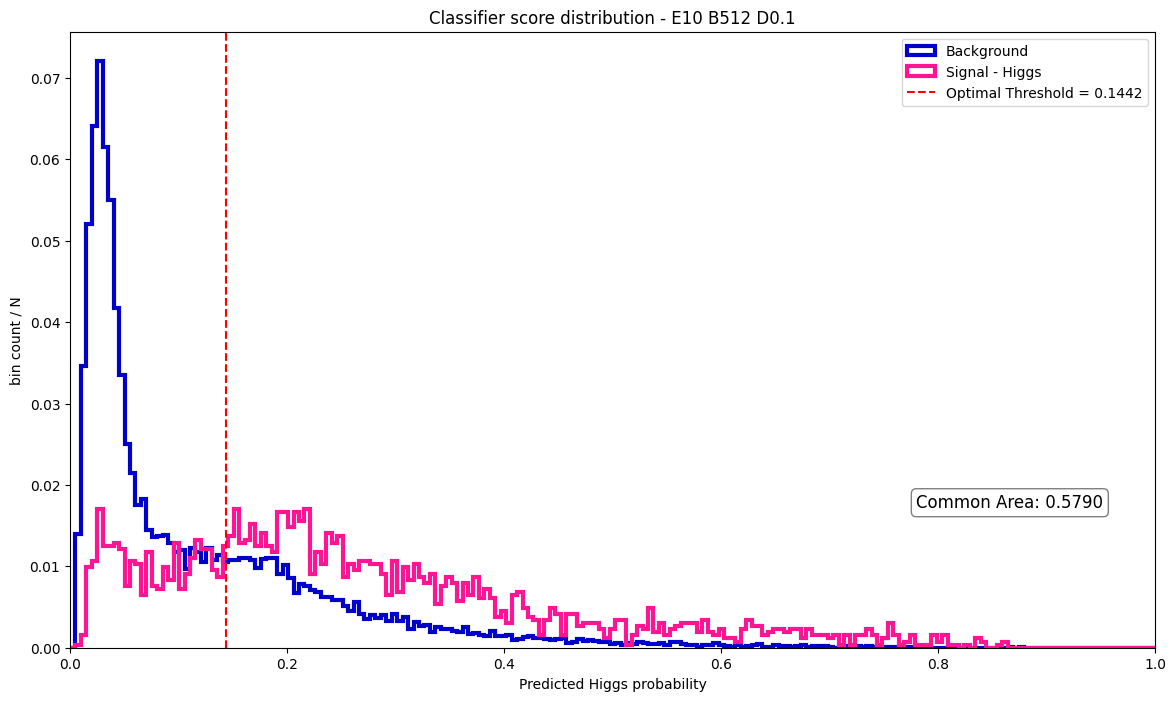

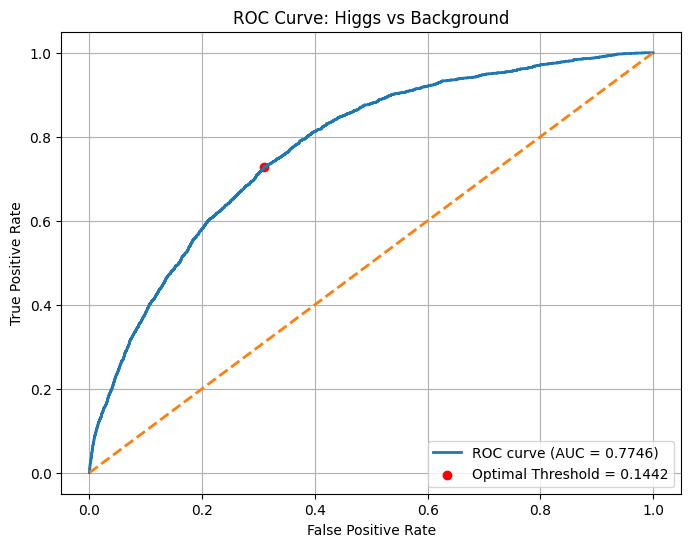

In [78]:
# Only if all events have been processed
if (count_bckg + count_higgs) == n_test_data:
    print("All events processed")

    # Define bins for classifier probabilities
    xbins = np.linspace(0.0, 1.0, 200)

    # Calculate histograms (density-normalized)
    hist_B, bin_edges = np.histogram(score_B, bins=xbins, density=True)
    hist_S, _         = np.histogram(score_S, bins=xbins, density=True)

    # Common area between the two densities
    bin_width   = bin_edges[1] - bin_edges[0]
    common_area = np.sum(np.minimum(hist_B, hist_S) * bin_width)

    # Combine scores and labels
    all_scores = np.array(score_S + score_B, dtype=float)
    all_labels = np.array([1] * len(score_S) + [0] * len(score_B), dtype=int)

    # ROC + AUC
    fpr, tpr, thresholds = roc_curve(all_labels, all_scores)
    roc_auc = auc(fpr, tpr)

    # Optimal threshold (Youden's J)
    j_scores = tpr - fpr
    optimal_idx = np.argmax(j_scores)
    optimal_threshold = thresholds[optimal_idx]
    print(f"Optimal Threshold: {optimal_threshold:.4f}")
    print(f"AUC: {roc_auc:.4f}")
    print(f"Common Area: {common_area:.4f}")

    # ---------- Plots ----------
    # Histograms
    style_b = {'facecolor': 'none', 'edgecolor': 'mediumblue', 'linewidth': 3}
    style_s = {'facecolor': 'none', 'edgecolor': 'deeppink',   'linewidth': 3}

    fig, ax = plt.subplots(figsize=(14, 8), dpi=100, facecolor='w', edgecolor='k')
    ax.set_xlim(0.0, 1.0)

    ax.hist(score_B, bins=xbins,
            weights=(1 / len(score_B)) * np.ones(len(score_B)),
            histtype='step', **style_b)
    ax.hist(score_S, bins=xbins,
            weights=(1 / len(score_S)) * np.ones(len(score_S)),
            histtype='step', **style_s)

    ax.axvline(optimal_threshold, color='red', linestyle='--',
               label=f"Optimal Threshold = {optimal_threshold:.4f}")

    ax.set_ylabel('bin count / N')
    ax.set_xlabel('Predicted Higgs probability')
    ax.set_title(f'Classifier score distribution - E{num_epochs} B{batch_size} D{dropout_rate}')

    ax.legend(['Background', 'Signal - Higgs', f"Optimal Threshold = {optimal_threshold:.4f}"])

    ax.text(0.78, 0.25, f'Common Area: {common_area:.4f}', transform=ax.transAxes, fontsize=12,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

    plt.show()
    plt.close()

    # ROC curve
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, lw=2, label=f"ROC curve (AUC = {roc_auc:.4f})")
    plt.plot([0, 1], [0, 1], lw=2, linestyle='--')
    plt.scatter(fpr[optimal_idx], tpr[optimal_idx], color='red',
                label=f"Optimal Threshold = {optimal_threshold:.4f}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve: Higgs vs Background")
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()
    plt.close()

else:
    print("Some events were not processed")